<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
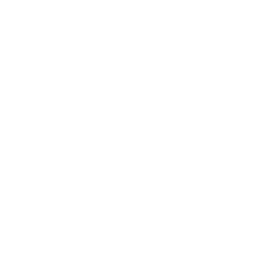
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">製造における故障モードのクラスタリング</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 製造 / 品質エンジニアリング &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

本例では、各故障イベントで記録された多次元のセンサー症状プロファイルから、繰り返し発生する**設備の故障モード**を発見します。8つの標準化された症状変数（振動、温度差、圧力低下、電流スパイク、騒音、サイクルタイム偏差、トルク分散、オイル粒子数）を、コンパクトでよく分離されたグループを好む**完全連結法による階層クラスタリング**（`PROC CLUSTER METHOD=COMPLETE`）でクラスタリングします。続いて`PROC TREE`が階層を**6つの故障モード**に分割し、`PROC FREQ`がそれらのモードを設備タイプおよびシフトとクロス集計して、体系的な関連性を検定します。

ここでの実行は**100イベントのサンプル**に対して行われます（この環境では出力が100オブザベーションに制限されます）。このサンプルでは、6つのモードはほぼ同じ大きさ（各 n = 16〜17）であり、主に設備タイプではなく**温度、圧力、振動**のシグネチャによって分離されます。モード×設備およびモード×シフトのクロス集計は、このサンプルサイズでは統計的に有意で**ありません**（カイ二乗の p はそれぞれ 0.15 と 0.07）。このワークフローは全イベント履歴に対しても変更なくスケールし、モードごとの件数が増えればこれらの関連性はより明確になります。

## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|---------|
| WORK.FAILURES | 設備故障イベントの症状プロファイル（合成データ） | 100 |
| WORK.FAILURES_STD | 症状を平均0、標準偏差1に標準化（`PROC STANDARD`） | 100 |
| WORK.FAILURE_TREE | 完全連結法のマージ履歴（`OUTTREE=`） | 100 |
| WORK.FAILURE_MODE_ASSIGNMENTS | `PROC TREE NCLUSTERS=6` による6モードへの分割 | 100 |

*この環境はライセンスなしモードで動作し、出力を100オブザベーションに制限します。合成データ生成器は20,000イベントを要求しますが、最初の100件のみが保持されます。以下の分析は完全にその100イベントのサンプルに基づいています。*

---

In [1]:
/* --------------------------------------------------------
   合成の故障イベント症状プロファイルを生成
   50台の設備にわたる20,000件の故障イベント
   -------------------------------------------------------- */
データ work.failures;
    呼出 streaminit(42);
    長さ equipment_type $24 shift $12;
    繰返 event_id = 1 から 20000;
        failure_id = cat('FE-', PUT(event_id, z6.));
        equip_num = int(rand('uniform') * 50) + 1;
        equipment_id = cat('EQ-', PUT(equip_num, z3.));
        /* 設備タイプ（配列ではなく if/else で日本語ラベルを割当） */
        etype_idx = int(rand('uniform') * 4) + 1;
        もし etype_idx = 1 なら equipment_type = 'プレス機';
        他 もし etype_idx = 2 なら equipment_type = 'コンベア';
        他 もし etype_idx = 3 なら equipment_type = 'ロボットアーム';
        他 equipment_type = '炉';
        /* シフト（日勤・夕勤・夜勤） */
        shift_idx = int(rand('uniform') * 3) + 1;
        もし shift_idx = 1 なら shift = '日勤';
        他 もし shift_idx = 2 なら shift = '夕勤';
        他 shift = '夜勤';
        failure_date = '01JAN2025'd + int(rand('uniform') * 365);
        /* 症状プロファイル：故障時点の8つのセンサー計測値 */
        vibration_level = round(rand('normal', 4.5, 2.1), 0.01);
        もし vibration_level < 0 なら vibration_level = 0;
        temperature_delta = round(rand('normal', 12, 8), 0.1);
        pressure_drop = round(rand('exponential') * 5, 0.01);
        current_spike = round(rand('normal', 1.2, 0.8), 0.01);
        もし current_spike < 0 なら current_spike = 0;
        noise_db = round(rand('normal', 78, 12), 1);
        cycle_time_deviation = round(rand('normal', 0, 3.5), 0.01);
        torque_variance = round(rand('exponential') * 2.5, 0.01);
        oil_particle_count = int(rand('exponential') * 150 + 10);
        downtime_minutes = round(rand('exponential') * 45 + 5, 1);
        出力;
    終了;
    削除 equip_num etype_idx shift_idx;
    書式 failure_date date9.;
実行;


NOTE: DATA work.failures

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.failures (100 rows, 15 columns).
NOTE: DATA elapsed:
  wall  7.40 seconds
  cpu   7.40 seconds


---

In [2]:
/* --------------------------------------------------------
   設備タイプ別のベースライン症状分布
   -------------------------------------------------------- */
処理 平均 データ=work.failures n mean std MAX;
    分類 equipment_type;
    変数 vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance oil_particle_count;
    見出 equipment_type='設備タイプ'
          vibration_level='振動レベル' temperature_delta='温度差(℃)'
          pressure_drop='圧力低下' current_spike='電流スパイク'
          noise_db='騒音(dB)' torque_variance='トルク分散'
          oil_particle_count='油中粒子数';
    表題 '設備タイプ別の故障症状プロファイル';
実行;

                                                   設備タイプ別の故障症状プロファイル                                                    

                                                  The MEANS Procedure

                                  Analysis Variable : vibration_level 振動レベル

        設備タイプ                          N Obs           Mean        Std Dev        Maximum
        ---------------------------------------------------------------------------------
        コンベア                              19      3.8089474      1.8662437      9.0400000
        プレス機                              30      4.6273333      2.1610740      9.9400000
        ロボットアーム                           25      3.5320000      1.9296070      6.7900000
        炉                                 26      4.3638462      2.0371177     10.1400000
        ---------------------------------------------------------------------------------

                                  Analysis Variable : temperature_delta 温度差(℃)

        設備タイプ      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                                   設備タイプ別の故障症状プロファイル                                                    




NOTE: PROC SGPLOT data=work.failures

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


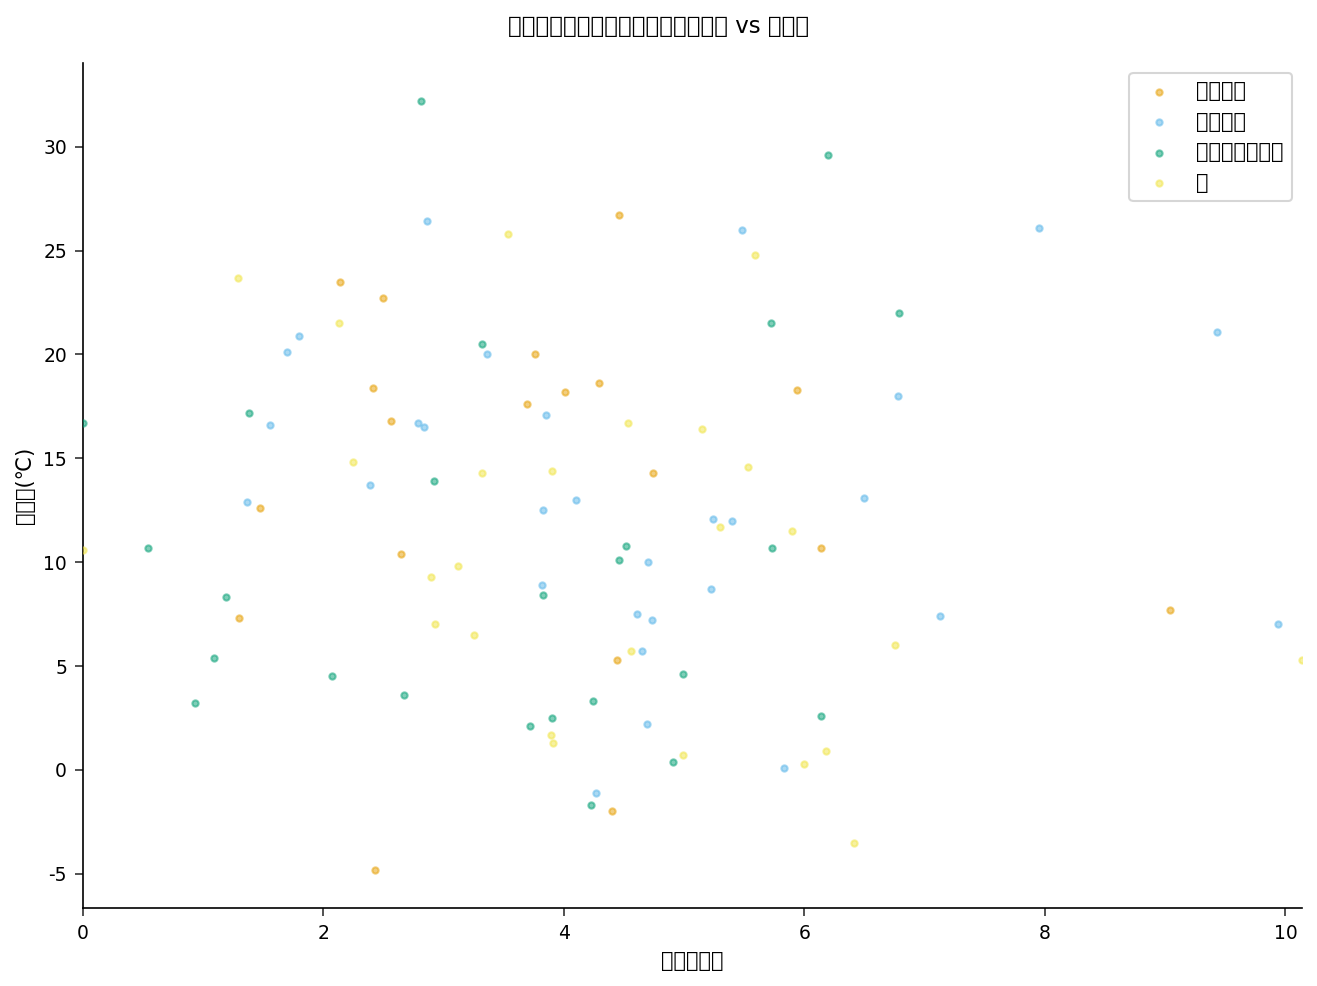

In [3]:
/* --------------------------------------------------------
   設備タイプ別の振動 vs 温度差
   -------------------------------------------------------- */
処理 SGPLOT データ=work.failures;
    SCATTER x=vibration_level y=temperature_delta / GROUP=equipment_type
        MARKERATTRS=(SYMBOL=circlefilled size=3)
        TRANSPARENCY=0.5;
    XAXIS 見出='振動レベル';
    YAXIS 見出='温度差(℃)';
    表題 '故障イベント：設備タイプ別の振動 vs 温度差';
実行;

---

In [4]:
/* --------------------------------------------------------
   クラスタリングのため症状変数を標準化
   -------------------------------------------------------- */
処理 標準 データ=work.failures out=work.failures_std
    mean=0 std=1;
    変数 vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
実行;


NOTE: PROC STANDARD data=work.failures

NOTE: Standardized 100 rows, 8 variables.


                                                   設備タイプ別の故障症状プロファイル                                                    

                                                 The CLUSTER Procedure
                                           Complete Linkage Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    99    FE-00005          FE-00006        2    0.0007    0.9993          1
    98    FE-00007          FE-00008        2    0.0007    0.9986          1
    97    FE-00000          FE-00004        2    0.0009    0.9977        1.2
    96    FE-00002          FE-00008        2    0.0009    0.9968        1.2
    95    FE-00000          FE-00001        2    0.0010    0.9958        1.3
    94    FE-00005          FE-00008        2    0.0011    0.9947        1.3
    93    FE-00004          CL99     


NOTE: PROC CLUSTER data=work.failures_std method=Complete

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 100 observations, 8 variables clustered using Complete method


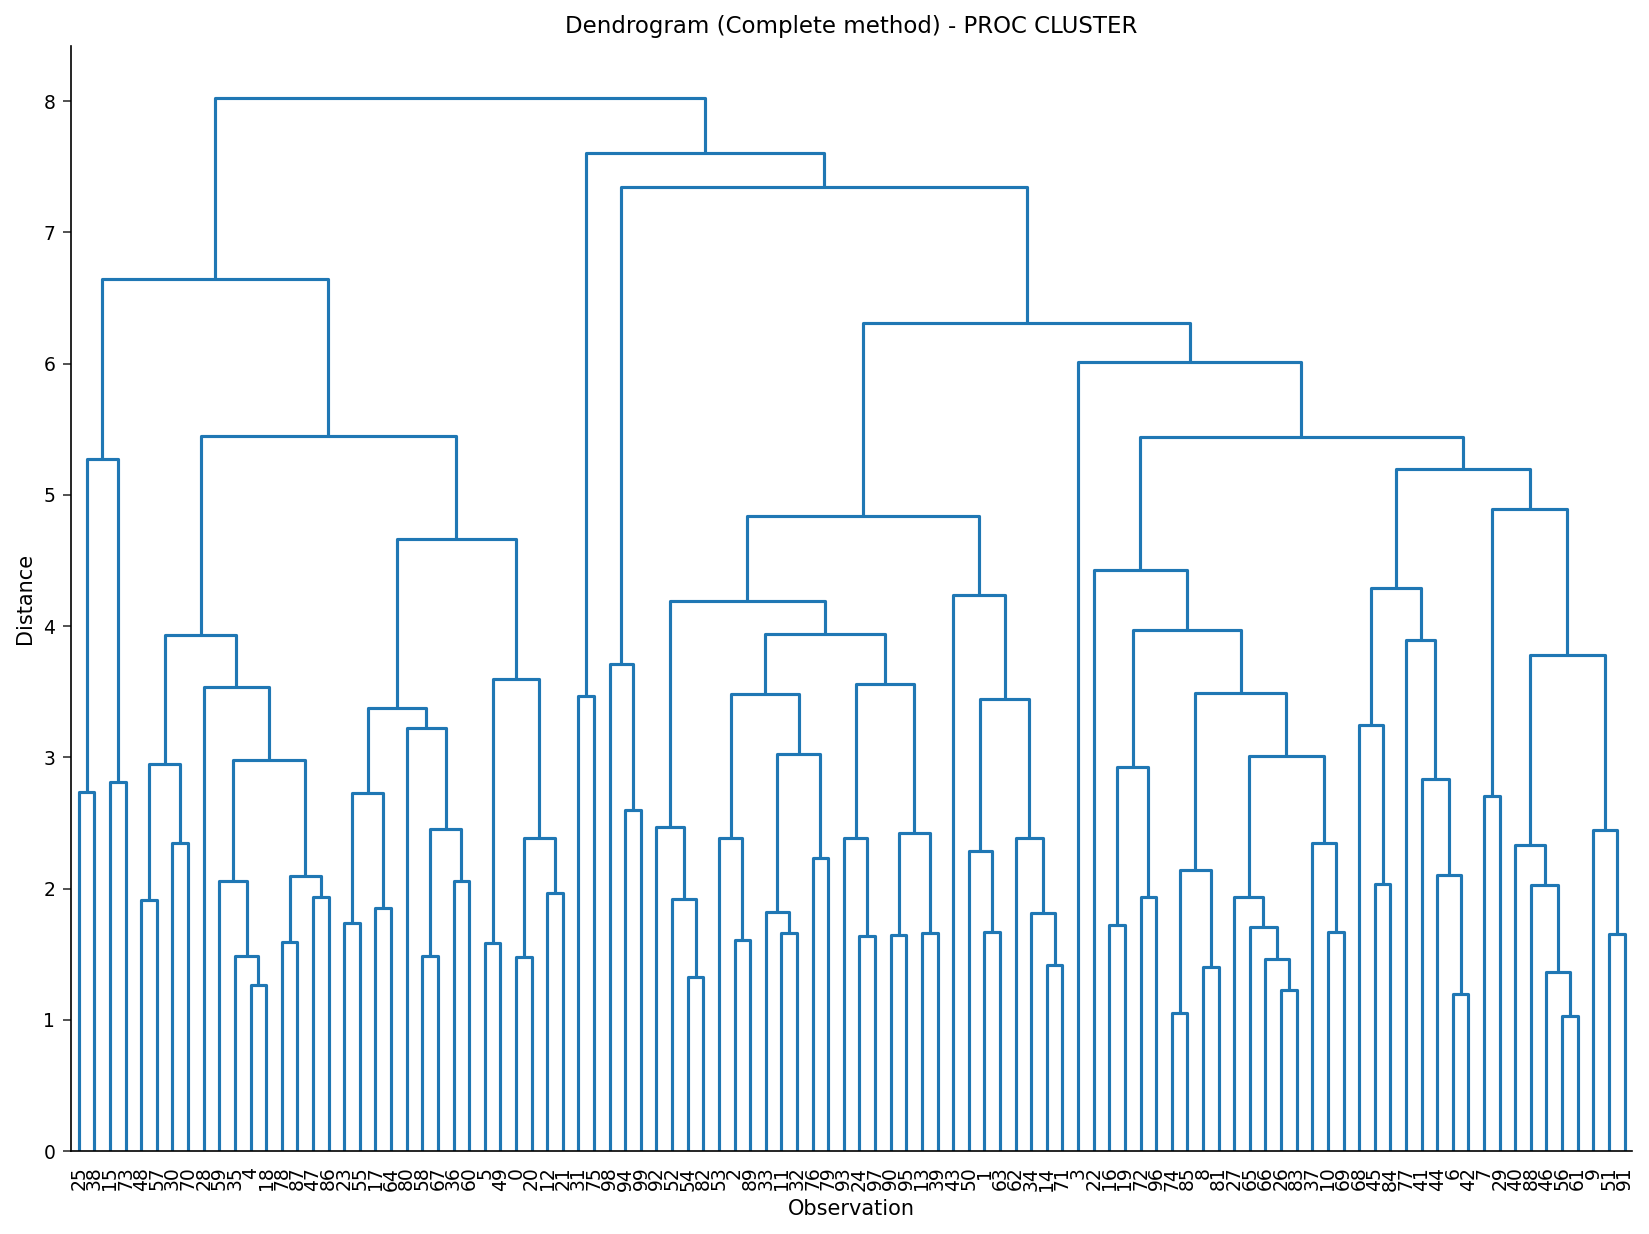

In [5]:
/* --------------------------------------------------------
   TRIM= による外れ値除去つきの完全連結法クラスタリング。
   TRIM=5 はクラスタ形成前に最も距離の大きい5%の
   オブザベーションを除去します。
   -------------------------------------------------------- */
処理 群 データ=work.failures_std METHOD=complete
    outtree=work.failure_tree
    pseudo 印刷=20 trim=5;
    変数 vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
    id failure_id;
実行;

In [6]:
/* --------------------------------------------------------
   完全連結法の階層を PROC TREE で6つの故障モードに
   分割します（NCLUSTERS=6）。6はトリアージにとって
   実用的で解釈しやすい粒度として選んでいます。上の
   デンドログラムは、この分割が区切るマージ構造を示します。
   -------------------------------------------------------- */
処理 TREE データ=work.failure_tree
    out=work.failure_mode_assignments
    nclusters=6;
    id failure_id;
実行;

                                                   設備タイプ別の故障症状プロファイル                                                    




NOTE: PROC TREE data=work.failure_tree

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: PROC TREE dendrogram SVG generated.
NOTE: PROC TREE: Extracted 6 clusters using Python/scipy


In [7]:
/* --------------------------------------------------------
   割当をマージし、故障モードをプロファイリング
   -------------------------------------------------------- */
データ work.failures_classified;
    結合 work.failures
          work.failure_mode_assignments(改名=(群=failure_mode));
    基準 failure_id;
実行;

処理 平均 データ=work.failures_classified n mean std;
    分類 failure_mode;
    変数 vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance
        oil_particle_count downtime_minutes;
    見出 failure_mode='故障モード'
          vibration_level='振動レベル' temperature_delta='温度差(℃)'
          pressure_drop='圧力低下' current_spike='電流スパイク'
          noise_db='騒音(dB)' torque_variance='トルク分散'
          oil_particle_count='油中粒子数' downtime_minutes='ダウンタイム(分)';
    表題 '故障モード別症状プロファイル（k=6）';
実行;

                                                  故障モード別症状プロファイル（k=6）                                                   

                                                  The MEANS Procedure

                                  Analysis Variable : vibration_level 振動レベル

        故障モード                    N Obs           Mean        Std Dev
        ------------------------------------------------------------
        1                           17      4.3470588      2.6168582
        2                           17      4.2552941      2.2610427
        3                           17      3.6870588      1.8669720
        4                           17      4.0500000      2.0351843
        5                           16      3.4793750      1.4636870
        6                           16      4.9693750      1.6907177
        ------------------------------------------------------------

                                  Analysis Variable : temperature_delta 温度差(℃)

        故障モード               


NOTE: DATA work.failures_classified

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.failures_classified (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                                    設備・シフト別の故障モード分布                                                     

                                                   The FREQ Procedure

Table of 故障モード by 設備タイプ

故障モード           |                 コンベア |                 プレス機 |              ロボットアーム |                    炉 |                 Total
----------------+----------------------+----------------------+----------------------+----------------------+----------------------
1               |                    4 |                    7 |                    1 |                    5 |                    17
----------------+----------------------+----------------------+----------------------+----------------------+----------------------
2               |                    3 |                    2 |                    7 |                    5 |                    17
----------------+----------------------+----------------------+----------------------+----------------------+-------------


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_failure_mode_equipment_type.spec.json
NOTE: ODS plot written: freq_mosaic_failure_mode_shift.spec.json
NOTE: PROC FREQ statement used.


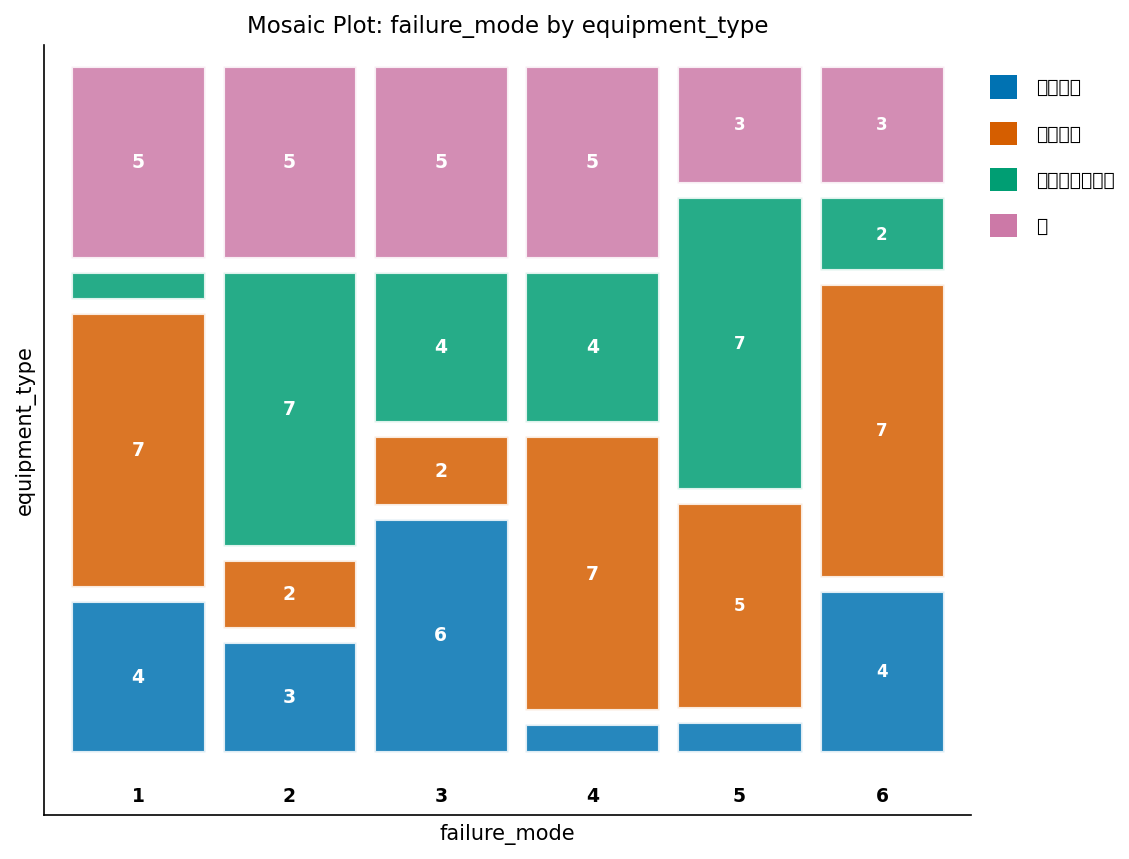

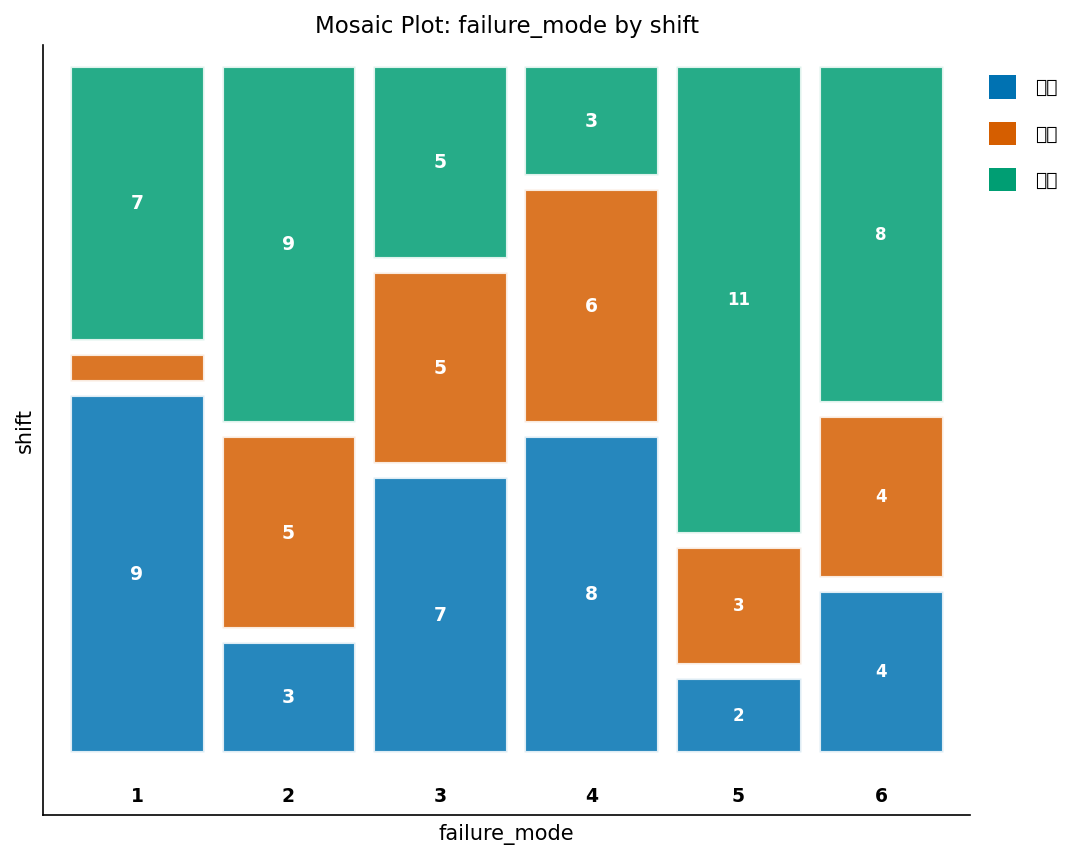

In [8]:
/* --------------------------------------------------------
   体系的なパターンを見つけるため、故障モードを設備タイプ
   およびシフトとクロス集計
   -------------------------------------------------------- */
処理 度数 データ=work.failures_classified;
    TABLES failure_mode * equipment_type / chisq nocol nopercent;
    TABLES failure_mode * shift / chisq nocol nopercent;
    見出 failure_mode='故障モード' equipment_type='設備タイプ' shift='シフト';
    表題 '設備・シフト別の故障モード分布';
実行;

---

### 解釈

100件の標準化された故障イベントに対する完全連結法クラスタリングは、ほぼ同じ大きさ（n = 17, 17, 17, 17, 16, 16）の**6つの故障モード**を生成します。これらのモードは、上記の`PROC MEANS`プロファイルにおける症状シグネチャによって区別されます。

- **モード6**は最も強い機械的ストレスのシグネチャを持ちます。平均振動が最大（4.97）、圧力低下が最大（7.51）、電流スパイクが最大（1.61）ですが、トルク分散は**最小**（1.28）です。
- **モード3**は熱的モードです。温度差が最大（16.3 C）で、平均騒音が最小（73.0 dB）です。
- **モード2**は他のモード（31〜52分）を大きく引き離して**最長のダウンタイム**（平均85.6分）を持ち、トルク分散も高く（3.57）、復旧コストの高いイベントを示唆します。
- **モード4**は最も軽度です。ダウンタイムが最小（31.4分）で、圧力低下とオイル粒子数は平均を下回ります。
- **モード1と5**は、単一の支配的な要因を持たない混合症状グループです。

`PROC FREQ`のクロス集計は、これらのモードが特定の設備やシフトに集中するかどうかを検定します。このサンプルサイズでは集中し**ません**。モード×設備タイプはカイ二乗 = 20.48（自由度15、p = 0.154、Cramer's V = 0.26）、モード×シフトはカイ二乗 = 17.13（自由度10、p = 0.072、Cramer's V = 0.29）で、いずれも0.05のしきい値を上回っており、さらにセルの80%以上で期待度数が5未満であるため、カイ二乗自体も示唆的なものに過ぎません。目に見える偏り（モード6がプレス機に、モード5が日勤シフトに傾く）は、ここでは有意ではなく記述的なものです。

**要点：**標準化された症状プロファイルに対する完全連結法は、温度、圧力、ダウンタイムを軸とする解釈可能な6モードの分類体系を生成します。モードが特定の設備やシフトに対応するかどうか——実行可能な根本原因の問い——を確認するには、クロス集計の検出力が不足するこの100イベントのサンプルではなく、全イベント履歴が必要です。

---

In [9]:
/* --------------------------------------------------------
   CMMS 連携のため故障分類をエクスポート
   -------------------------------------------------------- */
処理 EXPORT データ=work.failures_classified
    OUTFILE='failure_mode_classifications.csv'
    DBMS=csv REPLACE;
実行;


NOTE: PROC EXPORT data=work.failures_classified outfile=failure_mode_classifications.csv

NOTE: Exported 100 rows to failure_mode_classifications.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>